# GNN Graph Exploration and Visualization

This notebook explores the processed heterogeneous graph generated for fraud detection. We will examine the graph statistics, check for class imbalance, and visualize subgraphs to understand the relationships between transactions, users, and locations.

In [1]:
!pip install -q torch-geometric networkx matplotlib pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.4 MB/s eta 0:00:0000:01


In [3]:
import torch
from torch_geometric.data import HeteroData
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE

# Load the processed graph
data_path = '../data/processed_graph.pt'
data = torch.load(data_path, weights_only=False)

print("Graph Metadata:")
print(data)

Graph Metadata:
HeteroData(
  transaction={
    x=[50000, 28],
    y=[50000],
  },
  user={ num_nodes=8963 },
  location={ num_nodes=5 },
  merchant_category={ num_nodes=5 },
  (user, performs, transaction)={ edge_index=[2, 50000] },
  (transaction, performed_by, user)={ edge_index=[2, 50000] },
  (transaction, at, location)={ edge_index=[2, 50000] },
  (location, is_site_of, transaction)={ edge_index=[2, 50000] },
  (transaction, belongs_to, merchant_category)={ edge_index=[2, 50000] },
  (merchant_category, contains, transaction)={ edge_index=[2, 50000] }
)


## 1. Graph Statistics & Schema

Let's look at the counts for each node and edge type, and visualize the **Meta-Graph** (the high-level schema of our heterogeneous graph).

Node Statistics:


,Node Type,Count,Features Shape
0,transaction,50000,"(50000, 28)"
1,user,8963,N/A
2,location,5,N/A
3,merchant_category,5,N/A



Edge Statistics:


,Edge Type,Count
0,user -- performs -> transaction,50000
1,transaction -- performed_by -> user,50000
2,transaction -- at -> location,50000
3,location -- is_site_of -> transaction,50000
4,transaction -- belongs_to -> merchant_category,50000
5,merchant_category -- contains -> transaction,50000


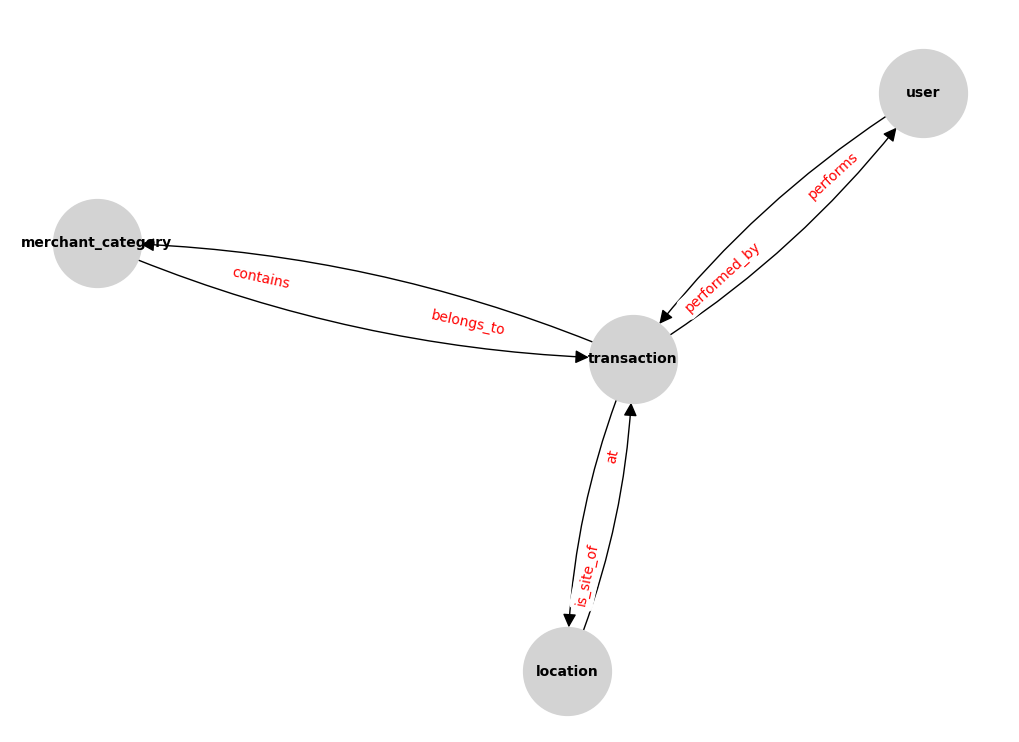

In [4]:
stats = {
    "Node Type": [],
    "Count": [],
    "Features Shape": []
}

for node_type in data.node_types:
    stats["Node Type"].append(node_type)
    stats["Count"].append(data[node_type].num_nodes)
    features = data[node_type].get('x', None)
    stats["Features Shape"].append(features.shape if features is not None else "N/A")

df_nodes = pd.DataFrame(stats)
print("Node Statistics:")
display(df_nodes)

edge_stats = {
    "Edge Type": [],
    "Count": []
}
for edge_type in data.edge_types:
    edge_stats["Edge Type"].append(f"{edge_type[0]} -- {edge_type[1]} -> {edge_type[2]}")
    edge_stats["Count"].append(data[edge_type].edge_index.shape[1])

df_edges = pd.DataFrame(edge_stats)
print("\nEdge Statistics:")
display(df_edges)

# Visualize Meta-Graph
def visualize_schema(data):
    G = nx.MultiDiGraph()
    for edge_type in data.edge_types:
        src, rel, dst = edge_type
        G.add_edge(src, dst, label=rel)
    
    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(G, k=2, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=4000, 
            font_size=10, font_weight='bold', arrowsize=20, connectionstyle='arc3, rad = 0.1')
    
    # Add edge labels
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', label_pos=0.3)
    
    plt.title("Heterogeneous Graph Schema (Meta-Graph)")
    plt.show()

visualize_schema(data)

## 2. Global View: t-SNE Projection of Transactions

Since visualizing 50,000 nodes as a graph is unreadable, we use **t-SNE** to project the 28 transaction features into 2D. This allows us to see if fraudulent transactions (red) cluster together in the feature space.

Running t-SNE on 5000 sampled transactions...


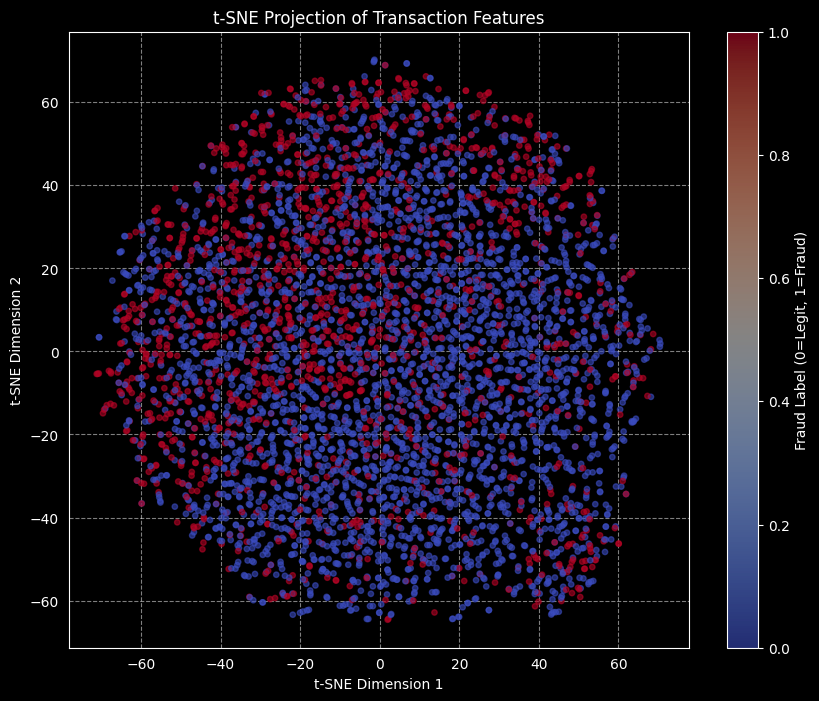

In [5]:
labels = data['transaction'].y.numpy()
features = data['transaction'].x.numpy()

# Sample 5000 points for speed
indices = np.random.choice(len(labels), 5000, replace=False)
sample_features = features[indices]
sample_labels = labels[indices]

print("Running t-SNE on 5000 sampled transactions...")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
features_2d = tsne.fit_transform(sample_features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=sample_labels, 
            cmap='coolwarm', alpha=0.6, s=15)
plt.colorbar(scatter, label='Fraud Label (0=Legit, 1=Fraud)')
plt.title("t-SNE Projection of Transaction Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. Local View: Subgraph Visualization

Let's zoom in on a specific user to see how their transactions are connected to locations and categories.

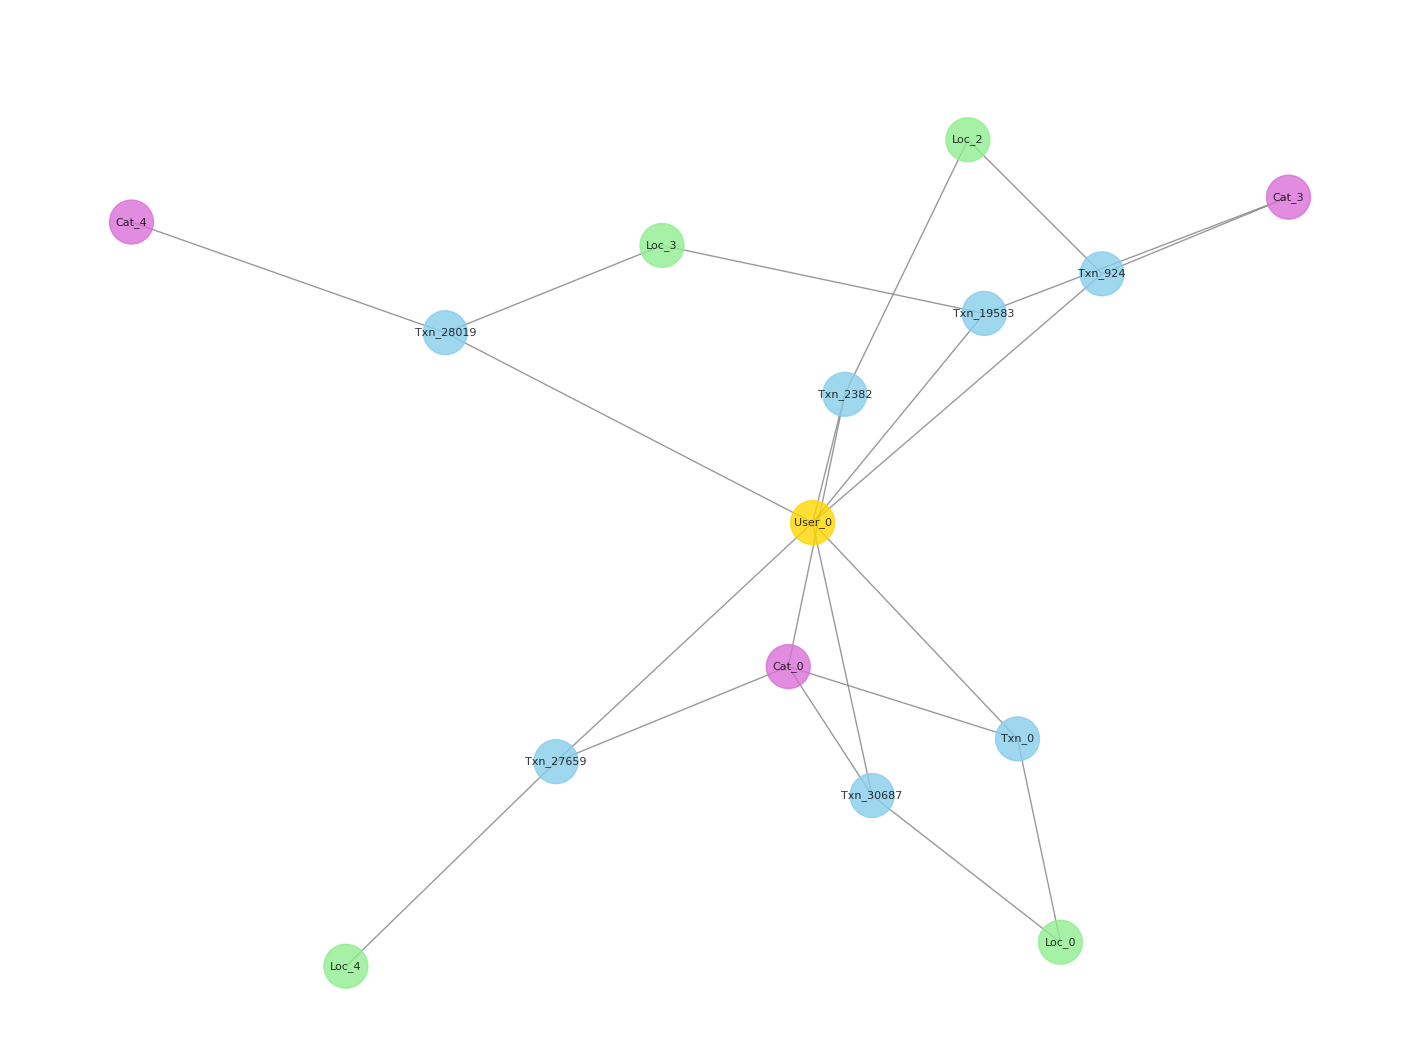

In [6]:
def visualize_user_subgraph(data, user_id_idx):
    G = nx.Graph()
    
    # 1. Find all transactions performed by this user
    edge_index = data['user', 'performs', 'transaction'].edge_index
    mask = edge_index[0] == user_id_idx
    txn_indices = edge_index[1][mask].numpy()
    
    user_node = f"User_{user_id_idx}"
    G.add_node(user_node, type='user')
    
    for txn_idx in txn_indices:
        txn_node = f"Txn_{txn_idx}"
        is_fraud = data['transaction'].y[txn_idx].item() == 1
        G.add_node(txn_node, type='transaction', fraud=is_fraud)
        G.add_edge(user_node, txn_node)
        
        # 2. Add Location connections
        loc_edges = data['transaction', 'at', 'location'].edge_index
        loc_idx = loc_edges[1][loc_edges[0] == txn_idx].item()
        loc_node = f"Loc_{loc_idx}"
        G.add_node(loc_node, type='location')
        G.add_edge(txn_node, loc_node)
        
        # 3. Add Category connections
        cat_edges = data['transaction', 'belongs_to', 'merchant_category'].edge_index
        cat_idx = cat_edges[1][cat_edges[0] == txn_idx].item()
        cat_node = f"Cat_{cat_idx}"
        G.add_node(cat_node, type='merchant_category')
        G.add_edge(txn_node, cat_node)

    # Drawing
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    
    node_colors = []
    for n, d in G.nodes(data=True):
        if d['type'] == 'user':
            node_colors.append('gold')
        elif d['type'] == 'location':
            node_colors.append('lightgreen')
        elif d['type'] == 'merchant_category':
            node_colors.append('orchid')
        else: # transaction
            node_colors.append('salmon' if d['fraud'] else 'skyblue')
            
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=1000, font_size=8, edge_color='gray', alpha=0.8)
    
    plt.title(f"Subgraph for User {user_id_idx}\n(Yellow=User, Blue=Legit, Red=Fraud, Green=Loc, Purple=Cat)")
    plt.show()

# Sample a user with multiple transactions
user_counts = torch.bincount(data['user', 'performs', 'transaction'].edge_index[0])
sample_user = torch.where(user_counts > 5)[0][0].item()

visualize_user_subgraph(data, sample_user)